# Scenario 2 — $100 annual DCA

Validation and exploration for the annual dollar-cost-averaging scenario: $100 invested on each yearly anniversary of the window start, ten deposits, terminal measured at month 120. Total contributed: $1,000.

Mirrors the structure of `01_lump_sum.ipynb` and uses the same `AnnualDCA100.compute_windows()` that `src/scenarios/annual_dca.py` exposes.

Run from the project root: `jupyter notebook notebooks/02_annual_dca.ipynb`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.scenarios.annual_dca import AnnualDCA100, HORIZON_YEARS
from src.analysis import rolling_window_returns

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 4)

## Load the monthly returns parquet

In [2]:
df = (
    pd.read_parquet(ROOT / 'data' / 'processed' / 'monthly_returns.parquet')
    .set_index('date')
    .sort_index()
)
print(f'Rows: {len(df):,}')
print(f'Span: {df.index.min().date()} to {df.index.max().date()}')
df.head()

Rows: 1,195
Span: 1926-08-31 to 2026-03-31


,nominal_return,real_return,rf,cpi,inflation
date,,,,,
1926-08-31,0.0289,0.0348,0.0025,17.4000,-0.0057
1926-09-30,0.0061,0.0004,0.0023,17.5000,0.0057
1926-10-31,-0.0295,-0.0350,0.0032,17.6000,0.0057
1926-11-30,0.0285,0.0227,0.0031,17.7000,0.0057
1926-12-31,0.0290,0.0290,0.0028,17.7000,0.0000


## Compute the rolling DCA windows

Each window starts at month `t` and runs for 10 years. Ten $100 deposits are made on yearly anniversaries (offsets 0, 12, …, 108 months) and each compounds from its deposit month to month 120. IRR is solved by bisection.


In [3]:
scenario = AnnualDCA100()
windows = scenario.compute_windows(df, HORIZON_YEARS).dropna()
print(f'{HORIZON_YEARS}-year DCA windows: {len(windows):,}')
windows.head()

10-year DCA windows: 1,076


,end_date,nominal_terminal,real_terminal,nominal_metric,real_metric
1926-08-31,1936-07-31,"1,565.5347","1,691.5559",0.0801,0.0937
1926-09-30,1936-08-31,"1,440.5227","1,551.5029",0.0654,0.0785
1926-10-31,1936-09-30,"1,548.4354","1,668.9900",0.0782,0.0914
1926-11-30,1936-10-31,"1,731.7137","1,861.5425",0.0978,0.1105
1926-12-31,1936-11-30,"1,778.7981","1,907.5232",0.1025,0.1148


## Sanity check #1 — 1990s bull decade

For the window starting 1990-01-31, the lump-sum CAGR is ~17.99%. Annual-DCA IRR should be **lower** here because most of the capital arrives later in the bull run and earns less compounding.

In [4]:
lump_nom = rolling_window_returns(df['nominal_return'], years=HORIZON_YEARS)
lump_real = rolling_window_returns(df['real_return'], years=HORIZON_YEARS)

for start in ['1990-01-31']:
    w = windows.loc[start]
    l = lump_nom.loc[start]
    print(f'Start {start} (end {w.end_date.date()})')
    print(f'  Lump-sum   $1,000 → ${l.terminal_value * 1000:,.0f}  ({l.cagr:.2%} CAGR)')
    print(f'  Annual DCA $1,000 → ${w.nominal_terminal:,.0f}  ({w.nominal_metric:.2%} IRR)')

Start 1990-01-31 (end 1999-12-31)
  Lump-sum   $1,000 → $5,230  (17.99% CAGR)
  Annual DCA $1,000 → $3,278  (20.89% IRR)


## Sanity check #2 — Lost decade (2000-01-31)

This is the textbook DCA-vs-lump-sum case. The lump-sum CAGR was ~−0.38% (money invested in Jan 2000 was worth less than $1,000 in Jan 2010, on a nominal basis). Under annual DCA, terminal should still come in **above** $1,000 nominal — later deposits caught lower prices.

In [5]:
for start in ['2000-01-31']:
    w = windows.loc[start]
    l = lump_nom.loc[start]
    print(f'Start {start} (end {w.end_date.date()})')
    print(f'  Lump-sum   $1,000 → ${l.terminal_value * 1000:,.0f}  ({l.cagr:.2%} CAGR)')
    print(f'  Annual DCA $1,000 → ${w.nominal_terminal:,.0f}  ({w.nominal_metric:.2%} IRR)')
    assert w.nominal_terminal > 1000, 'DCA terminal should beat break-even even when lump-sum CAGR is negative'

Start 2000-01-31 (end 2009-12-31)
  Lump-sum   $1,000 → $963  (-0.38% CAGR)
  Annual DCA $1,000 → $1,102  (1.77% IRR)


## Rolling IRR over time

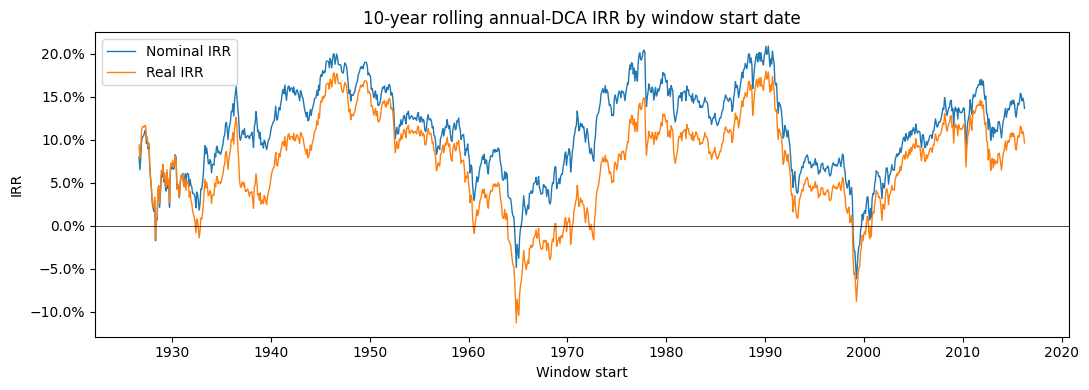

In [6]:
fig, ax = plt.subplots()
ax.plot(windows.index, windows['nominal_metric'], label='Nominal IRR', linewidth=1)
ax.plot(windows.index, windows['real_metric'], label='Real IRR', linewidth=1)
ax.axhline(0, color='black', linewidth=0.5)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.set_title(f'{HORIZON_YEARS}-year rolling annual-DCA IRR by window start date')
ax.set_xlabel('Window start')
ax.set_ylabel('IRR')
ax.legend()
plt.tight_layout()
plt.show()

## Distribution of rolling IRRs

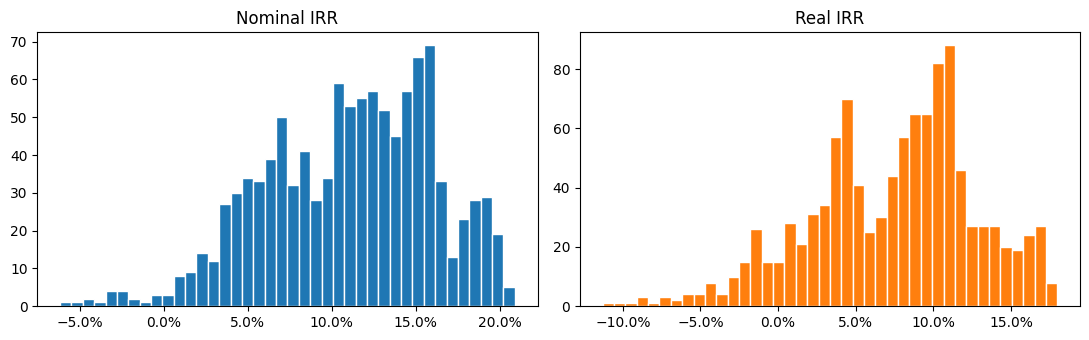

Nominal IRR <= 0: 1.86% (20 of 1,076)
Real IRR    <= 0: 9.67% (104 of 1,076)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(windows['nominal_metric'], bins=40, edgecolor='white')
axes[0].set_title('Nominal IRR')
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
axes[1].hist(windows['real_metric'], bins=40, edgecolor='white', color='C1')
axes[1].set_title('Real IRR')
axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

nom_neg = (windows['nominal_metric'] <= 0).mean()
real_neg = (windows['real_metric'] <= 0).mean()
print(f'Nominal IRR <= 0: {nom_neg:.2%} ({(windows["nominal_metric"] <= 0).sum():,} of {len(windows):,})')
print(f'Real IRR    <= 0: {real_neg:.2%} ({(windows["real_metric"]    <= 0).sum():,} of {len(windows):,})')

## Best and worst 10-year DCA windows

In [8]:
print('Best nominal DCA windows:')
print(windows.nlargest(5, 'nominal_metric')[['end_date', 'nominal_metric', 'nominal_terminal']])
print('\nWorst nominal DCA windows:')
print(windows.nsmallest(5, 'nominal_metric')[['end_date', 'nominal_metric', 'nominal_terminal']])

Best nominal DCA windows:
             end_date  nominal_metric  nominal_terminal
1990-04-30 2000-03-31          0.2090        3,281.2119
1990-01-31 1999-12-31          0.2089        3,278.3173
1977-09-30 1987-08-31          0.2045        3,196.1211
1990-09-30 2000-08-31          0.2033        3,174.0702
1977-08-31 1987-07-31          0.2030        3,169.4030

Worst nominal DCA windows:
             end_date  nominal_metric  nominal_terminal
1999-03-31 2009-02-28         -0.0617          716.2376
1964-10-31 1974-09-30         -0.0485          768.4611
1999-04-30 2009-03-31         -0.0467          775.8484
1999-02-28 2009-01-31         -0.0449          783.6234
1965-01-31 1974-12-31         -0.0378          813.9562


In [9]:
print('Best real DCA windows:')
print(windows.nlargest(5, 'real_metric')[['end_date', 'real_metric', 'real_terminal']])
print('\nWorst real DCA windows:')
print(windows.nsmallest(5, 'real_metric')[['end_date', 'real_metric', 'real_terminal']])

Best real DCA windows:
             end_date  real_metric  real_terminal
1990-01-31 1999-12-31       0.1799     2,773.5536
1990-04-30 2000-03-31       0.1789     2,758.4775
1946-04-30 1956-03-31       0.1778     2,740.3038
1946-05-31 1956-04-30       0.1774     2,734.4946
1946-08-31 1956-07-31       0.1769     2,726.4583

Worst real DCA windows:
             end_date  real_metric  real_terminal
1964-10-31 1974-09-30      -0.1131       548.1338
1965-01-31 1974-12-31      -0.1043       573.3951
1964-12-31 1974-11-30      -0.0946       602.6983
1999-03-31 2009-02-28      -0.0879       624.1561
1964-11-30 1974-10-31      -0.0857       631.4409


## DCA vs. lump-sum side by side

Scatter the annual-DCA IRR against the lump-sum CAGR for the same window starts. Bull decades sit below the 45° line (DCA loses because most capital arrives late); flat or down decades sit above it (DCA wins because later deposits buy at lower prices).

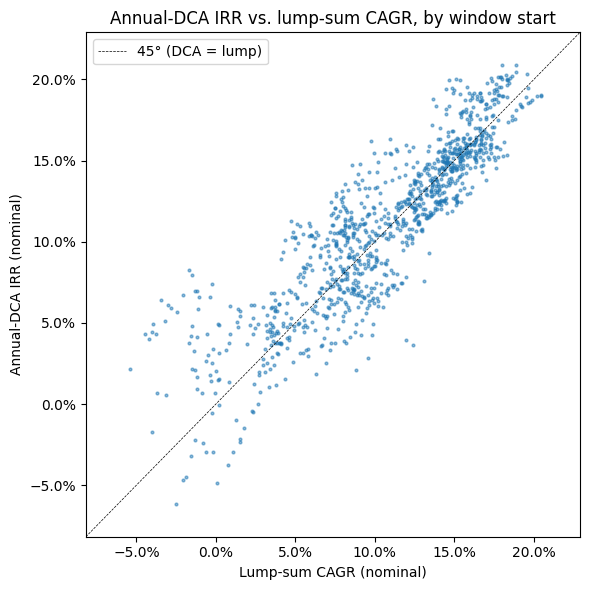

In [10]:
joined = windows[['nominal_metric']].join(
    lump_nom['cagr'].rename('lump_cagr'),
    how='inner',
)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(joined['lump_cagr'], joined['nominal_metric'], s=4, alpha=0.5)
lim = (joined.min().min() - 0.02, joined.max().max() + 0.02)
ax.plot(lim, lim, color='black', linewidth=0.5, linestyle='--', label='45° (DCA = lump)')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.set_xlabel('Lump-sum CAGR (nominal)')
ax.set_ylabel('Annual-DCA IRR (nominal)')
ax.set_title('Annual-DCA IRR vs. lump-sum CAGR, by window start')
ax.legend()
plt.tight_layout()
plt.show()